# NLMEM Preconditionner simulation study
Le document suivant résume l'étude de simulation pour la modèle à effets-mixtes non linéaire

## Model sepecification
Le modèle que l'on souhaite étudier est le suivant : 

$$Y_{i,j} = \frac{\varphi_{1,i}}{1+ \exp\left(\frac{-(t_{i,j}- \xi_i}\tau\right)}$$

Où $\xi_i = \beta^T X + \varphi_{2,i}$ et $\varphi  \sim \mathcal N(\mu, \Gamma^2)$

Le code ci-dessous le définie pour python.

In [1]:
from abc import abstractmethod
import functools

import numpy as np
import jax.numpy as jnp
import jax.random as jrd
from jax import jit
import parametrization_cookbook.jax as pc

import sdg4varselect.plot as sdgplt
from sdg4varselect.models import (
    AbstractMixedEffectsModel,
    AbstractHDModel,
    cov_simulation,
)


class HDLogisticMixedEffectsModel(AbstractMixedEffectsModel, AbstractHDModel):
    """define a logistic mixed effects model"""

    def __init__(self, N=1, J=1, P=1, **kwargs):
        super().__init__(
            N=N,
            J=J,
            me_name=["phi1", "phi2"],  # mixed-effect name's
            **kwargs,
        )
        AbstractHDModel.__init__(self, P=P)
        self.init()

    @property
    def name(self):
        """return a str called name, based on the parameter of the model"""
        return f"LogisticMEM_N{self.N}_J{self.J}_P{self.P}"

    def init(self):
        """here you define the parametrization of the model
        and don't forget to call the mother init function at the end"""
        self._parametrization = pc.NamedTuple(
            mean_latent=pc.NamedTuple(
                mu1=pc.RealPositive(scale=100),
                mu2=pc.RealPositive(scale=2000),
            ),
            tau=pc.RealPositive(scale=100),
            cov_latent=pc.MatrixDiagPosDef(dim=2, scale=(100, 2000)),
            var_residual=pc.RealPositive(scale=100),
            beta=pc.Real(scale=10, shape=(self.P,)),
        )
        AbstractHDModel.init_dim(self)

    # ============================================================== #
    @functools.partial(jit, static_argnums=0)
    def mixed_effect_function(
        self,
        params,
        times: jnp.ndarray,  # shape = (J,) [None, :]
        phi1: jnp.ndarray,  # shape = (N,) [:,None]
        phi2: jnp.ndarray,  # shape = (N,) [:,None]
        cov: jnp.ndarray,  # shape = (N,p)
        **kwargs,
    ) -> jnp.ndarray:  # shape = (N,J)
        """logistic_curve
        phi1 = supremum
        phi2 = midpoint
        tau = growth rate
        """
        ksi = cov @ params.beta + phi2

        out = phi1[:, None] / (1 + jnp.exp(-(times - ksi[:, None]) / params.tau))
        assert out.shape == times.shape
        return out

    # ============================================================== #

    @abstractmethod
    def sample(
        self,
        params_star,
        prngkey,
        **kwargs,
    ):
        """Sample one data set for the model"""

        (prngkey_time, prngkey_mem, prngkey_cov) = jrd.split(prngkey, num=3)

        # === nlmem_simulation() === #
        time = jnp.linspace(100, 1800, self.J)
        time = jnp.tile(time, (self.N, 1))

        cov = cov_simulation(prngkey_cov, cov_min=-1, cov_max=1, shape=(self.N, self.P))

        obs, sim = AbstractMixedEffectsModel.sample(
            self, params_star, prngkey_mem, mem_obs_time=time, cov=cov
        )

        return {"mem_obs_time": time, "cov": cov} | obs, sim

Les temps d'observation sont dans $[100,1800]$ échantillionné de manière régulière afin d'obtenir $J$ observation par individu.

Les covariables sont tirées selon une uniforme entre $[-1,1]$ puis recentré (selon les colonnes).

La fonction "init" ci dessus définie la parametrization utilisé pour $\theta$. Elle nomme également les composante de $\theta$. $cov_latent$, la matrice de variance-covariance des variables latentes, est définie comme une matrice diagonale positive de dimension 2 : $\theta$ aura alors 4 composantes nommé respectivement cov_latent1, cov_latent2, cov_latent3, cov_latent4. Evidement cov_latent2 = cov_latent3 = 0 et cov_latent1 et cov_latent2 sont les variances des $\gamma_1^2$ et  $\gamma_2^2$

## Theta star 

Ci dessous on définie $\theta^*$ la valeur utilisé lors des simulations des data-set, ie la valeur que l'on souhaite retrouver en fin d'estimation. On se place dans tout ce qui suis dans le cas où $N = 200,J=15$ et $ P = 500$

In [11]:
myModel = HDLogisticMixedEffectsModel(N=200, J=15, P=500)

p_star = myModel.new_params(
    mean_latent={"mu1": 100, "mu2": 1200},
    cov_latent=jnp.diag(jnp.array([50, 2000])),
    tau=150,
    var_residual=30,
    beta=jnp.concatenate(
        [jnp.array([300, 100, 50]), jnp.zeros(shape=(myModel.P - 3,))]
    ),
)

p_star = myModel.new_params(
    mean_latent={"mu1": 100, "mu2": 1200},
    cov_latent=jnp.diag(jnp.array([50, 1000])),
    tau=150,
    var_residual=30,
    beta=jnp.concatenate([jnp.array([100, 80, 50]), jnp.zeros(shape=(myModel.P - 3,))]),
)

# Results loading

On charge ici les resultats de simulations pour différent scénarios

In [3]:
import pandas as pd
from sdg4varselect.outputs import TestResults, MultiRunRes

m = HDLogisticMixedEffectsModel
config = [
    {"name": "Fisher", "seed_name": "S(1, 10)"},
    # {"name": "Fisher", "seed_name": "Snotf(1, 10)"},
    # {"name": "adagrad", "seed_name": "S(1, 10)"},
    # {"name": "adagrad", "seed_name": "S(1, 2)"},
    # {"name": "adagrad2", "seed_name": "S(1, 10)"},
    {"name": "fisheradagrad", "seed_name": "S(1, 11)"},
]
config = [
    {"name": "Fisher", "seed_name": "200_S(1, 9)"},
    {"name": "Fisher", "seed_name": "1000_S(1, 9)"},
    {"name": "Fisher", "seed_name": "2000_S(1, 9)"},
]
config = [
    {"name": "Fisher", "seed_name": "S(1, 10)"},
]

results = TestResults(
    [
        TestResults.load(
            m(N=200, J=15, P=100),
            "files",
            filename_add_on=f"{c['seed_name']}_{c['name']}",
        )
        for c in config
    ],
    config,
)
nrun_to_keep = min([len(t) for t in results])
results = TestResults(
    [t.reduce_number_run(nrun_to_keep) for t in results], results.config
)

print(f"chrono = {[str(t.chrono) for t in results]}")
print([len(t) for t in results])
scenarios_labels = [c["name"] for c in config]

files/LogisticMEM_N200_J15_P100_S(1, 10)_Fisher LOADED !
chrono = ['6 days, 20:32:35.940059']
[10]


## Results plot

In [4]:
results.last_theta[:, :, -1, 6].shape

(1, 10)

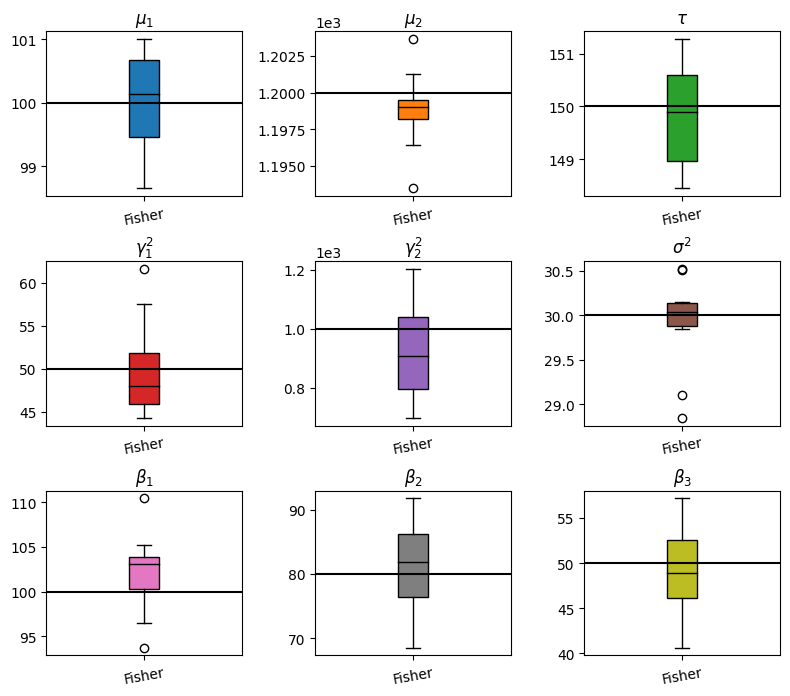

In [12]:
id_to_plot = jnp.array([1, 2, 3, 4, 7, 8, 9, 10, 11]) - 1
scenarios_labels = [x[7:] for x in results.get_scenarios_labels("name")]

params_names = np.array(
    [
        "$\\mu_1$",
        "$\\mu_2$",
        "$\\tau$",
        "$\\gamma_1^2$",
        "$\\gamma_2^2$",
        "$\sigma^2$",
        "$\\beta_1$",
        "$\\beta_2$",
        "$\\beta_3$",
    ]
)

x = results.last_theta[:, :, -1, id_to_plot]
fig = sdgplt.boxplot_estimation(
    x=x.T,
    hline=myModel.hstack_params(p_star)[id_to_plot],
    xlabels=scenarios_labels,
    title=params_names,  # myModel.params_names[id_to_plot],
    nrows=3,
    ncols=3,
    fig=sdgplt.figure(height=7, width=8),
)
fig.tight_layout()
for ax in fig.axes:
    ax.tick_params(axis="x", labelrotation=10)

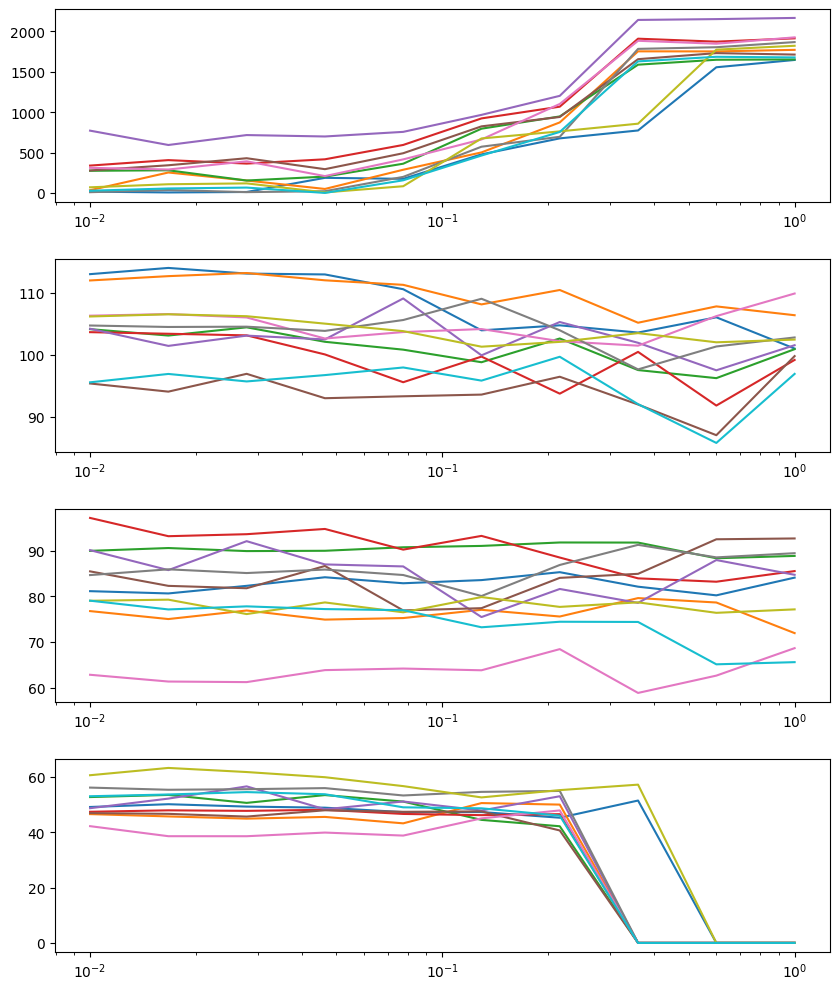

In [7]:
fig = sdgplt.figure(10, 10)
subfigs = fig.subfigures(4, 1)

subfigs[0].subplots(1, 1).plot(
    results[0][0].lbd_set,
    jnp.array([[r.last_theta[1, 6] for r in run] for run in results[0]]).T,
)

subfigs[0].axes[0].set_xscale("log")

for i in range(3):
    subfigs[i + 1].subplots(1, 1).plot(
        results[0][0].lbd_set,
        jnp.array([[r.last_theta[1, 8 + i] for r in run] for run in results[0]]).T,
    )

    subfigs[i + 1].axes[0].set_xscale("log")

TypeError: 'SubFigure' object is not subscriptable

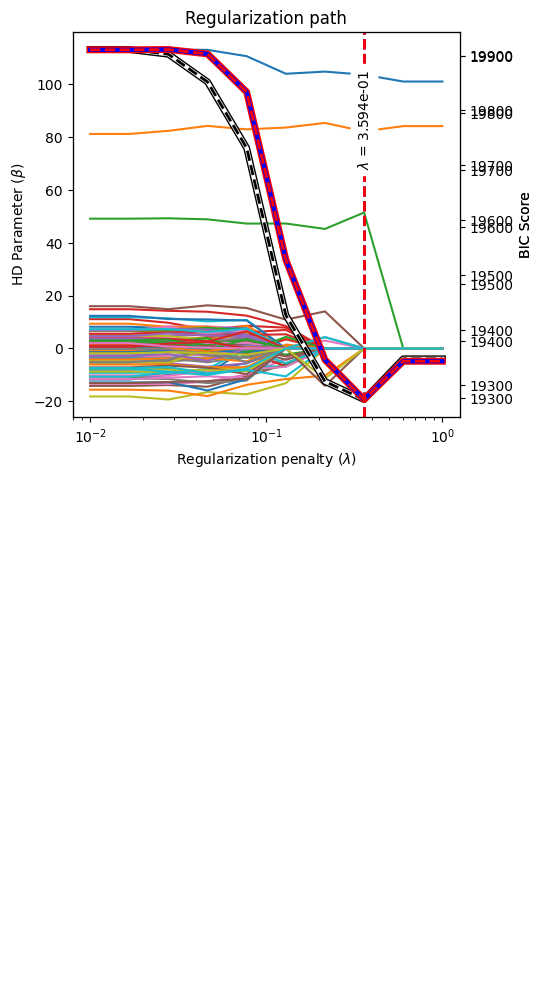

In [8]:
from sdg4varselect._regularization_function import eBIC

fig = sdgplt.figure(10, 5 * len(results))
subfigs = fig.subfigures(2, len(results))

for i in range(len(results)):
    for j in range(subfigs.shape[0]):
        reg = results[i][j].standardize()
        ax = sdgplt.plot_reg_path(
            reg_res=reg,
            dim_ld=myModel.DIM_LD,
            fig=subfigs[j][i] if len(subfigs.shape) == 2 else subfigs[i],
        )

        x = jnp.array([r.last_theta[1, myModel.DIM_LD :] for r in reg])
        t = jnp.array([xx[~jnp.isnan(xx)] for xx in x])

        ebic = eBIC(
            t,
            jnp.array([r.likelihood[1] for r in reg]),
            myModel.N * (1 + myModel.J),
        )
        sdgplt._plot_bic(
            ax=ax.axes[0],
            lbd_set=reg.lbd_set,
            bic=ebic,
            argmin_bic=jnp.argmin(ebic),
            colors=["r", "b", "r"],
            msg="eBIC",
        )

        subfigs[j][i].axes[0].set_title("")

    subfigs[0][i].axes[0].set_title(results.config[i]["name"])

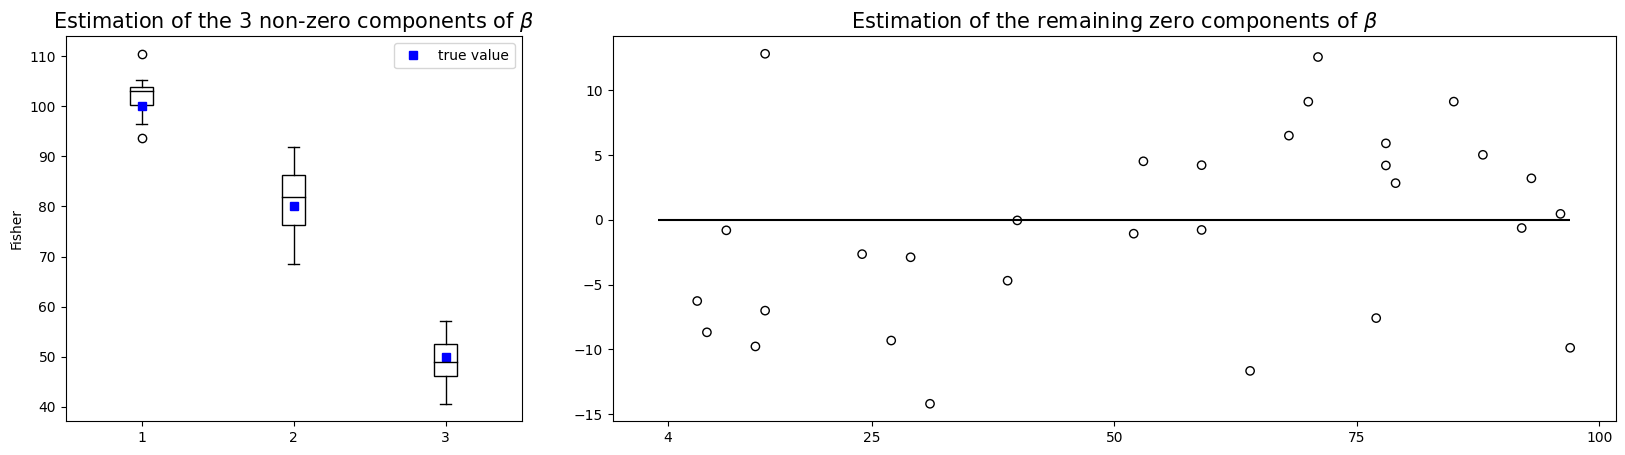

In [13]:
_ = sdgplt.plot_2_panel_selected_theta_hd(
    results,
    myModel.hstack_params(p_star),
    scenarios_labels,
    dim_ld=myModel.DIM_LD,
    fig=sdgplt.figure(5, 20),
    theta_name="$\\beta$",
)